<h1>The Stacked bar charts</h1>

<p>The only way we actually use the stacked bar charts is to plot frameworks or CDRs to show the diversity of the selected panel</p>
<p>Lets suppose we have the panel of VHHs, which is stored in the document that has CDR1 column</p>
<p>I will use the Observed antibody space dataset fraction</p>
<p>The data that is used in this example: <a href = "https://github.com/isgcodingclub/KnowledgeTransfer/blob/main/datasets/SRR24716325_1_Paired_All.csv">Download dataset from here</a></p>
<p>Skip the first row to read the table correctly</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Preparing the data for plotting 
df = pd.read_csv("SRR24716325_1_Paired_All.csv", skiprows = 1)
list_CDR1 = df["cdr1_aa_heavy"].to_list()
# for the purpose of this exercise we are going to focus on the CDR1 length of 8
list_CDR1_8 = [a for a in list_CDR1 if len(a) == 8]

# We will need this dictionary to make the graph
amino_acids_dict = {
    'A': [], 'C': [], 'D': [], 'E': [], 'F': [], 'G': [], 'H': [], 'I': [],
    'K': [], 'L': [], 'M': [], 'N': [], 'P': [], 'Q': [], 'R': [], 'S': [],
    'T': [], 'V': [], 'W': [], 'Y': [], '*': [], "X": []
}
# This dictionary is the colour scheme that we use to color amino acid bars
dict_colours_codes = {
    'A': '#800000', 'C': '#cc0000', 'D': '#ff3300', 'E': '#ff6600', 'F': '#ff9900',
    'G': '#ffcc00', 'H': '#ffff00', 'I': '#ccff33', 'K': '#99cc00', 'L': '#33cc33',
    'M': '#339933', 'N': '#43682b', 'P': '#660066', 'Q': '#9900cc', 'R': '#9966ff',
    'S': '#6699ff', 'T': '#0000ff', 'V': '#000099', 'W': '#cc9900', 'Y': '#996633',
    "*": "#6b8a73", "X": "#a10d2d"}

# Lets convert the list of CDRs to dataframe
splitted_CDRs = pd.DataFrame([list(a) for a in list_CDR1_8])
splitted_CDRs.head()
                                                        
        

,0,1,2,3,4,5,6,7
0,G,F,T,F,S,D,F,Y
1,G,F,T,F,S,D,F,Y
2,G,F,S,F,S,S,D,W
3,G,F,T,F,S,N,D,W
4,G,Y,T,F,T,A,Y,H


In [3]:
# Filling the dictionary by counting the percentage of each amino acid at each position.
for position in range(0, 8):
    for aa in amino_acids_dict:
        amino_acid_count = splitted_CDRs[position].to_list().count(aa) # how many instances of each amino acid there is in each column
        amino_acid_percentage = amino_acid_count/len(splitted_CDRs)*100  # what percentage of the each column each amino acid comprises
        amino_acids_dict[aa].append(amino_acid_percentage)
print(amino_acids_dict)

{'A': [5.754716981132075, 0.7547169811320755, 1.0377358490566038, 0.0, 0.2830188679245283, 1.8867924528301887, 2.4528301886792456, 21.32075471698113], 'C': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5660377358490566, 0.18867924528301888], 'D': [0.09433962264150944, 0.8490566037735849, 0.09433962264150944, 0.09433962264150944, 2.2641509433962264, 25.849056603773583, 1.3207547169811322, 2.2641509433962264], 'E': [0.37735849056603776, 0.2830188679245283, 0.0, 0.0, 0.09433962264150944, 0.7547169811320755, 0.0, 0.0], 'F': [0.0, 72.64150943396226, 0.0, 91.0377358490566, 0.0, 0.09433962264150944, 20.754716981132077, 0.09433962264150944], 'G': [92.83018867924528, 9.245283018867925, 0.09433962264150944, 0.0, 2.1698113207547167, 7.3584905660377355, 0.09433962264150944, 10.471698113207548], 'H': [0.0, 0.2830188679245283, 0.09433962264150944, 0.0, 0.0, 0.18867924528301888, 6.415094339622642, 0.9433962264150944], 'I': [0.0, 0.6603773584905661, 2.6415094339622645, 4.245283018867925, 0.9433962264150944, 0.7547

<p>Now after we filled the dictionary we can plot the graph</p>

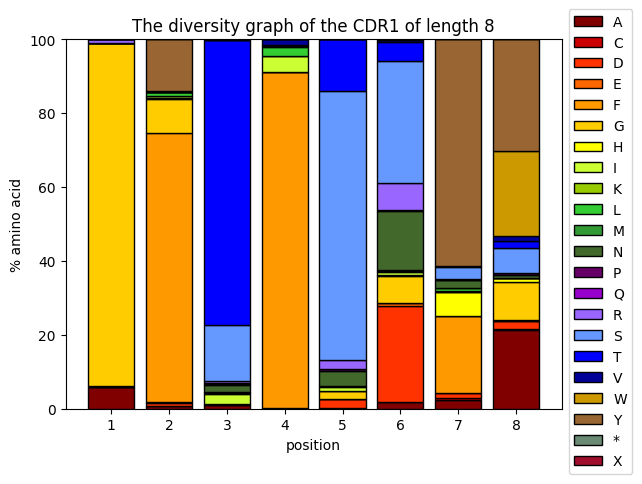

In [4]:

fig, ax = plt.subplots()
x = list(range(1, 9))
bottom_val = np.zeros(8) # creating empty array
for key, val in amino_acids_dict.items():
    ax.bar(x, np.array(val), bottom = bottom_val, color = dict_colours_codes[key], edgecolor = "k", label = key)
    bottom_val += np.array(val)
ax.legend(bbox_to_anchor=(1, 1.1), loc="upper left")
ax.set_title("The diversity graph of the CDR1 of length 8")
ax.set_ylabel("% amino acid")
ax.set_xlabel("position")
plt.show()
